## <span style="color: #ff7402">__Atelier Préparation Données Images__</span>

Contexte 
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître 
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des 
déchets. 

Le modèle devra classer chaque image dans l'une des catégories suivantes : 

* cardboard : cartons ondulés, cartons plats, … 
* plastic : bouteilles, emballages plastiques... 
* paper : feuilles,  journaux... 
* glass : bouteilles et objets en verre... 
* metal : canettes, boîtes métalliques... 
* trash : emballages bonbons, tasses jetables, ... 

Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas 
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images 
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images 
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées.

L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à 
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning. 

### <span style="color: #ffe602">__Partie 1 – Exploration du dataset__</span>

Un programme Python capable de récupérer, pour chaque image, son nom, sa classe, 
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa 
taille.

Construction d'un script simple pour auditer le dossier data/raw/ et extraire les caractéristiques techniques de chaque image avec la bibliothèque standard de gestion de fichiers en Python (os ou pathlib) et la bibliothèque de traitement d'images incontournable : Pillow (PIL).

In [1]:
import os
import pandas as pd
from PIL import Image

# 1. Définition du chemin vers les données brutes
CHEMIN_RAW = "../data/raw"

# 2. Liste pour stocker les informations de chaque image
liste_informations = []

# 3. Parcours des dossiers de chaque classe dans data/raw
for nom_classe in os.listdir(CHEMIN_RAW):
    chemin_classe = os.path.join(CHEMIN_RAW, nom_classe)
    
    # On s'assure qu'on parcourt bien un dossier (ex: cardboard, glass...)
    if os.path.isdir(chemin_classe):
        
        # Parcours de chaque fichier dans le dossier de la classe
        for nom_fichier in os.listdir(chemin_classe):
            chemin_image = os.path.join(chemin_classe, nom_fichier)
            
            # Pour éviter de traiter des fichiers système cachés (ex: .DS_Store)
            if nom_fichier.startswith('.'):
                continue
                
            # Initialisation d'un dictionnaire avec les infos de base
            info_image = {
                "nom": nom_fichier,
                "classe": nom_classe,
                "format": None,
                "mode": None,
                "largeur": None,
                "hauteur": None,
                "ecart_type": None,
                "canaux": None,
                "taille_octets": os.path.getsize(chemin_image), # Taille du fichier sur le disque
                "statut": "Valide"
            }
            
            try:
                # Tentative d'ouverture de l'image avec Pillow
                with Image.open(chemin_image) as img:
                    # On force le chargement pour vérifier si le fichier est réellement corrompu
                    img.verify() 
                    
                # On réouvre l'image pour lire ses propriétés (verify() ferme le fichier)
                with Image.open(chemin_image) as img:
                    info_image["format"] = img.format  # Ex: JPEG, PNG
                    info_image["mode"] = img.mode      # Ex: RGB, L (Grayscale)
                    info_image["largeur"] = img.size[0]
                    info_image["hauteur"] = img.size[1]
                    
                    # Détermination du nombre de canaux selon le mode
                    # RGB = 3 canaux, RGBA = 4 canaux, L (noir et blanc) = 1 canal
                    info_image["canaux"] = len(img.getbands())
                    
                    # Pour l'écart-type, on convertit temporairement en niveaux de gris 
                    # afin d'avoir une seule valeur globale simple pour cette étape
                    statistiques = img.convert("L").getextrema() 
                    # Note : getbands/histogram peut donner l'écart-type, mais pour faire simple
                    # et efficace sans numpy à ce stade, on peut aussi charger les données en niveaux de gris
                    import math
                    stat_visuelles = Image.Image.getdata(img.convert("L"))
                    # Version simplifiée pour débutant sans charger de grosse matrice :
                    # On utilise l'astuce de stocker temporairement la variance ou une valeur par défaut
                    # Mais pour être précis et performant, on peut importer brièvement numpy ici :
                    import numpy as np
                    matrice_pixels = np.array(img)
                    info_image["ecart_type"] = round(float(np.std(matrice_pixels)), 2)

            except Exception as e:
                # Si une erreur survient, le fichier est marqué comme corrompu
                info_image["statut"] = "Corrompu"
            
            # Ajout des données de l'image actuelle à notre liste
            liste_informations.append(info_image)

# 4. Conversion de la liste en DataFrame Pandas pour visualiser le résultat
df_exploration = pd.DataFrame(liste_informations)

# Affichage des 10 premières lignes du résultat
print("Aperçu des données explorées :")
print(df_exploration.head(10))


C:\Users\cissc\AppData\Local\Temp\ipykernel_19408\2156876818.py:63: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  stat_visuelles = Image.Image.getdata(img.convert("L"))


Aperçu des données explorées :
                nom     classe format mode  largeur  hauteur  ecart_type  \
0    cardboard1.jpg  cardboard   JPEG  RGB    512.0    384.0       40.59   
1   cardboard10.jpg  cardboard   JPEG  RGB    512.0    384.0       42.57   
2  cardboard100.jpg  cardboard   JPEG  RGB    512.0    384.0       46.11   
3  cardboard101.jpg  cardboard   JPEG  RGB    512.0    384.0       72.26   
4  cardboard102.jpg  cardboard   JPEG  RGB    512.0    384.0       48.39   
5  cardboard103.jpg  cardboard   JPEG  RGB    512.0    384.0       40.74   
6  cardboard104.jpg  cardboard   JPEG  RGB    512.0    384.0       38.82   
7  cardboard105.jpg  cardboard   JPEG  RGB    512.0    384.0       49.68   
8  cardboard106.jpg  cardboard   JPEG  RGB    512.0    384.0       57.07   
9  cardboard107.jpg  cardboard   JPEG  RGB    512.0    384.0       41.68   

   canaux  taille_octets  statut  
0     3.0          17333  Valide  
1     3.0          21683  Valide  
2     3.0          14884  V

### <span style="color: #ffde07">__Partie 2 – Détection des images corrompues__</span> 

Une fonction qui détecte une image corrompue. 

Une image est considérée comme corrompue lorsque le fichier est endommagé (téléchargement incomplet, bug d'écriture sur le disque, format non reconnu).

In [2]:
# Fonction de detection d'image corrompue

from PIL import Image

def est_image_corrompue(chemin_fichier):
    """
    Vérifie si une image est corrompue ou illisible.
    Renvoie True si l'image est corrompue, False sinon.
    """
    try:
        with Image.open(chemin_fichier) as img:
            # La méthode verify() vérifie la structure du fichier sans décoder les pixels
            img.verify()
        return False  # Si aucune erreur n'est levée, l'image n'est pas corrompue
    except Exception:
        return True   # Si une erreur survient, l'image est corrompue


In [3]:
# Utilisation de la fonction de detection pour vérifier les images dans notre dossier raw

# Chemin vers nos images brutes
CHEMIN_RAW = "../data/raw"

# Liste pour stocker les chemins des images corrompues trouvées
images_corrompues = []

# Parcours des sous-dossiers de classes
for nom_classe in os.listdir(CHEMIN_RAW):
    chemin_classe = os.path.join(CHEMIN_RAW, nom_classe)
    
    if os.path.isdir(chemin_classe):
        for nom_fichier in os.listdir(chemin_classe):
            # Ignorer les fichiers système cachés
            if nom_fichier.startswith('.'):
                continue
                
            chemin_complet = os.path.join(chemin_classe, nom_fichier)
            
            # Appel de notre fonction
            if est_image_corrompue(chemin_complet):
                images_corrompues.append({
                    "Nom": nom_fichier,
                    "Classe": nom_classe,
                    "Chemin": chemin_complet
                })

# Affichage du bilan
print(f"Nombre total d'images corrompues détectées : {len(images_corrompues)}")
if len(images_corrompues) > 0:
    print("\nListe des images corrompues :")
    for img in images_corrompues:
        print(f"- Classe [{img['Classe']}] : Fichier {img['Nom']}")


Nombre total d'images corrompues détectées : 6

Liste des images corrompues :
- Classe [cardboard] : Fichier cardboard83.jpg
- Classe [glass] : Fichier glass74.jpg
- Classe [metal] : Fichier metal48.jpg
- Classe [paper] : Fichier paper213.jpg
- Classe [plastic] : Fichier plastic13.jpg
- Classe [trash] : Fichier trash3.jpg


### <span style="color: #e2c717">__Partie 3 – Détection des images vides__</span> 

Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image 
entièrement blanche ou image dont les pixels présentent très peu de variation. 

Une image est considérée comme vide ou quasi vide si tous ses pixels ont la même couleur ou si leurs nuances sont extrêmement proches.

Pour mesurer cela de manière scientifique et simple, on utilise l'écart-type (standard deviation ou std en anglais) des pixels :

* Si l'image est entièrement noire ou entièrement blanche, l'écart-type est strictement égal à 0 (aucune variation).

* Si l'image contient un léger bruit de fond ou une couleur unie imparfaite (un fond gris ou blanc continu), l'écart-type sera très proche de 0 (très peu de variation).

In [4]:
# Fonction de detection des images vides

def est_image_vide(chemin_fichier, seuil_variation=2.0):
    """
    Détecte si une image est entièrement noire, blanche ou presque uniforme.
    Se base sur l'écart-type des pixels en niveaux de gris.
    
    seuil_variation : Écart-type en dessous duquel l'image est considérée comme vide.
    """
    try:
        with Image.open(chemin_fichier) as img:
            # 1. On convertit l'image en niveaux de gris ('L') pour avoir une seule matrice d'analyse
            img_gris = img.convert('L')
            
            # 2. On transforme l'image en tableau de nombres (Numpy array)
            tableau_pixels = np.array(img_gris)
            
            # 3. On calcule l'écart-type de toutes les valeurs du tableau
            ecart_type = np.std(tableau_pixels)
            
            # 4. Si la variation est inférieure au seuil choisi, l'image est jugée vide
            if ecart_type < seuil_variation:
                return True
            else:
                return False
                
    except Exception:
        # Si l'image est corrompue et impossible à ouvrir, on ne la traite pas ici 
        # (elle a déjà été gérée dans la Partie 2)
        return False


In [5]:
# Utilisation de la fonction de detection pour vérifier les images dans notre dossier raw

CHEMIN_RAW = "../data/raw"
images_vides = []

# Parcours des sous-dossiers
for nom_classe in os.listdir(CHEMIN_RAW):
    chemin_classe = os.path.join(CHEMIN_RAW, nom_classe)
    
    if os.path.isdir(chemin_classe):
        for nom_fichier in os.listdir(chemin_classe):
            if nom_fichier.startswith('.'):
                continue
                
            chemin_complet = os.path.join(chemin_classe, nom_fichier)
            
            # On applique notre fonction de détection
            if est_image_vide(chemin_complet, seuil_variation=2.0):
                images_vides.append({
                    "Nom": nom_fichier,
                    "Classe": nom_classe,
                    "Chemin": chemin_complet
                })

# Bilan de la détection
print(f"Nombre total d'images vides ou uniformes détectées : {len(images_vides)}")
if len(images_vides) > 0:
    print("\nListe des images problématiques trouvées :")
    for img in images_vides:
        print(f"- Classe [{img['Classe']}] : Fichier {img['Nom']}")


Nombre total d'images vides ou uniformes détectées : 4

Liste des images problématiques trouvées :
- Classe [cardboard] : Fichier image-blanche-512x384.jpg
- Classe [glass] : Fichier image-noire-512x384.png
- Classe [metal] : Fichier image-blanche-512x384.jpg
- Classe [metal] : Fichier image-noire-512x384.png


### <span style="color: #dcc00d">__Partie 4 – Détecter les différences de résolution__</span> 

1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus 
fréquentes et le nombre d'images par résolution.

Puisqu'on a déjà extrait les informations de base lors de la Partie 1 dans un tableau Pandas (df_exploration), on va réutiliser ce tableau pour faire nos calculs de manière très simple et rapide.

Note : On prend soin de filtrer notre tableau pour ne travailler que sur les images "Valides" (en excluant les images corrompues qui n'ont pas de dimensions).

In [ ]:
# 1. On filtre le DataFrame de la Partie 1 pour ne garder que les images valides
df_valides = df_exploration[df_exploration["statut"] == "Valide"].copy()

# 2. Création d'une colonne "resolution" sous forme de texte (ex: "800x600") pour faciliter les calculs
df_valides["resolution"] = df_valides.apply(lambda row: f"{row['largeur']}x{row['hauteur']}", axis=1)

# 3. Calcul des résolutions minimales et maximales
# On cherche l'image avec la plus petite et la plus grande surface (largeur x hauteur)
df_valides["surface"] = df_valides["largeur"] * df_valides["hauteur"]

id_min = df_valides["surface"].idxmin()
id_max = df_valides["surface"].idxmax()

res_minimale = df_valides.loc[id_min, "resolution"]
res_maximale = df_valides.loc[id_max, "resolution"]

# 4. Compter le nombre d'images par résolution et identifier les plus fréquentes
distribution_res = df_valides["resolution"].value_counts()

# AFFICHAGE DES RÉSULTATS 
print("BILAN DE LA RÉSOLUTION DES IMAGES")
print(f"Résolution minimale trouvée : {res_minimale} (Surface : {df_valides.loc[id_min, 'surface']} px)")
print(f"Résolution maximale trouvée : {res_maximale} (Surface : {df_valides.loc[id_max, 'surface']} px)")
print("\nDISTRIBUTION DES RÉSULTATIONS (Nombre d'images par résolution)")
print(distribution_res)

print("\nLES RÉSUTIONS LES PLUS FRÉQUENTES (Top 3)")
print(distribution_res.head(3))


BILAN DE LA RÉSOLUTION DES IMAGES
Résolution minimale trouvée : 32.0x32.0 (Surface : 1024.0 px)
Résolution maximale trouvée : 512.0x384.0 (Surface : 196608.0 px)

DISTRIBUTION DES RÉSULTATIONS (Nombre d'images par résolution)
resolution
512.0x384.0    1013
32.0x32.0         5
48.0x32.0         4
40.0x40.0         4
Name: count, dtype: int64

LES RÉSUTIONS LES PLUS FRÉQUENTES (Top 3)
resolution
512.0x384.0    1013
32.0x32.0         5
48.0x32.0         4
Name: count, dtype: int64


2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. 

On définit donc un seuil strict : si la largeur est inférieure à 64 OU si la hauteur est inférieure à 64, l'image est rejetée.

Identifions toutes les images ne respectant pas cette contrainte.

In [8]:
# Identification des images trop petites

# 1. On filtre pour n'analyser que les images valides
df_valides = df_exploration[df_exploration["statut"] == "Valide"].copy()

# 2. Application du filtre : largeur < 64 OU hauteur < 64
df_trop_petites = df_valides[(df_valides["largeur"] < 64) | (df_valides["hauteur"] < 64)]

# 3. Affichage du bilan
print("DÉTECTION DES IMAGES TROP PETITES (< 64x64 px) ")
print(f"Nombre d'images ne respectant pas la contrainte : {len(df_trop_petites)}")

if len(df_trop_petites) > 0:
    print("\nListe des images trop petites à exclure :")
    # On affiche le nom, la classe et les dimensions réelles pour vérification
    print(df_trop_petites[["nom", "classe", "largeur", "hauteur"]].to_string(index=False))
else:
    print("\nBonne nouvelle ! Toutes les images valides font au moins 64x64 pixels.")


DÉTECTION DES IMAGES TROP PETITES (< 64x64 px) 
Nombre d'images ne respectant pas la contrainte : 13

Liste des images trop petites à exclure :
             nom    classe  largeur  hauteur
cardboard117.jpg cardboard     48.0     32.0
 cardboard22.jpg cardboard     32.0     32.0
 cardboard70.jpg cardboard     40.0     40.0
    glass100.jpg     glass     40.0     40.0
     glass15.jpg     glass     48.0     32.0
     glass21.jpg     glass     32.0     32.0
     glass23.jpg     glass     32.0     32.0
    metal121.jpg     metal     48.0     32.0
      metal2.jpg     metal     32.0     32.0
     metal26.jpg     metal     40.0     40.0
     paper10.jpg     paper     32.0     32.0
     paper54.jpg     paper     40.0     40.0
     paper64.jpg     paper     48.0     32.0


### <span style="color: #fe0d7a">__Partie 5 – Détection des différents canaux__</span> 

#### <span style="color: #f04793">Détermination du nombre d'images selon leur nombre de canaux.</span> 

On va à nouveau exploiter notre tableau Pandas df_exploration de la Partie 1. On va filtrer sur les images valides et utiliser la fonction .value_counts() sur la colonne canaux.

In [11]:
# 1. On ne garde que les images valides
df_valides = df_exploration[df_exploration["statut"] == "Valide"].copy()

# 2. On compte le nombre d'images pour chaque quantité de canaux
distribution_canaux = df_valides["canaux"].value_counts()

# 3. On extrait aussi la distribution selon le mode de l'image (RGB, L, RGBA...) pour plus de précision
distribution_modes = df_valides["mode"].value_counts()

# AFFICHAGE DES RÉSULTATS 
print("ANALYSE DES CANAUX DE COULEUR ")
print("Nombre d'images selon leur nombre de canaux :")
for canaux, nb_images in distribution_canaux.items():
    print(f"- {int(canaux)} canal/canaux : {nb_images} image(s)")

print("\nDÉTAIL PAR MODE PIL")
for mode, nb_images in distribution_modes.items():
    print(f"- Mode '{mode}' : {nb_images} image(s)")


ANALYSE DES CANAUX DE COULEUR 
Nombre d'images selon leur nombre de canaux :
- 3 canal/canaux : 1006 image(s)
- 4 canal/canaux : 18 image(s)
- 1 canal/canaux : 2 image(s)

DÉTAIL PAR MODE PIL
- Mode 'RGB' : 1006 image(s)
- Mode 'RGBA' : 18 image(s)
- Mode 'P' : 2 image(s)


### <span style="color: #fe0d7a">__Partie 6 – Détection des doublons__</span> 

Écrire et se servir d’une fonction qui détecte les doublons 

Pour trouver ces doublons de manière ultra-rapide et fiable sans comparer les images pixel par pixel (ce qui prendrait des heures), on utilise la technique du hachage cryptographique (hashing).

On va lire le fichier sous forme de octets et le passer dans un algorithme (comme MD5 ou SHA-256). Cet algorithme génère une "empreinte digitale" unique (une chaîne de caractères fixe).

In [13]:
# Fonction de hashage pour identifier les doublons

import hashlib

def calculer_empreinte_md5(chemin_fichier):
    """
    Calcule l'empreinte MD5 unique d'un fichier.
    Permet d'identifier si deux fichiers ont un contenu identique.
    """
    hash_md5 = hashlib.md5()
    try:
        # On ouvre le fichier en mode lecture binaire ('rb')
        with open(chemin_fichier, "rb") as f:
            # On lit le fichier par blocs de 4096 octets pour être efficace
            for bloc in iter(lambda: f.read(4096), b""):
                hash_md5.update(bloc)
        return hash_md5.hexdigest()  # Renvoie l'empreinte sous forme de texte
    except Exception:
        # En cas d'erreur de lecture (fichier corrompu), on renvoie None
        return None


In [14]:
# Scanne du dataset et identification des doublons

CHEMIN_RAW = "../data/raw"

# Dictionnaire pour lister : { empreinte_md5: [liste_des_chemins_de_fichiers] }
empreintes_globales = {}
doublons_detectes = []

# Parcours des sous-dossiers
for nom_classe in os.listdir(CHEMIN_RAW):
    chemin_classe = os.path.join(CHEMIN_RAW, nom_classe)
    
    if os.path.isdir(chemin_classe):
        for nom_fichier in os.listdir(chemin_classe):
            if nom_fichier.startswith('.'):
                continue
                
            chemin_complet = os.path.join(chemin_classe, nom_fichier)
            
            # Calcul de l'empreinte du fichier
            empreinte = calculer_empreinte_md5(chemin_complet)
            
            if empreinte:
                if empreinte in empreintes_globales:
                    # L'empreinte existe déjà -> on a trouvé un doublon !
                    empreintes_globales[empreinte].append(chemin_complet)
                    doublons_detectes.append({
                        "Fichier_Original": empreintes_globales[empreinte][0],
                        "Fichier_Doublon": chemin_complet,
                        "Empreinte": empreinte
                    })
                else:
                    # Première fois qu'on voit cette empreinte
                    empreintes_globales[empreinte] = [chemin_complet]

# RECOMPTE ET BILAN 
print("DÉTECTION DES IMAGES EN DOUBLON")
print(f"Nombre total de fichiers en doublon trouvés : {len(doublons_detectes)}")

if len(doublons_detectes) > 0:
    print("\nExemples de doublons trouvés (Fichier original VS sa copie) :")
    # On affiche les 5 premiers doublons pour vérifier
    for i, d in enumerate(doublons_detectes[:5]):
        print(f"{i+1}. Original : {d['Fichier_Original']}")
        print(f"   Doublon  : {d['Fichier_Doublon']}")
        print("-" * 50)

DÉTECTION DES IMAGES EN DOUBLON
Nombre total de fichiers en doublon trouvés : 15

Exemples de doublons trouvés (Fichier original VS sa copie) :
1. Original : ../data/raw\cardboard\image-violet-512x384.gif
   Doublon  : ../data/raw\glass\image-violet-512x384.gif
--------------------------------------------------
2. Original : ../data/raw\cardboard\image-blanche-512x384.jpg
   Doublon  : ../data/raw\metal\image-blanche-512x384.jpg
--------------------------------------------------
3. Original : ../data/raw\glass\image-noire-512x384.png
   Doublon  : ../data/raw\metal\image-noire-512x384.png
--------------------------------------------------
4. Original : ../data/raw\metal\metal125.jpg
   Doublon  : ../data/raw\metal\metal125po.jpg
--------------------------------------------------
5. Original : ../data/raw\metal\metal35.jpg
   Doublon  : ../data/raw\metal\metal35rt.jpg
--------------------------------------------------


 Pourquoi traquer les doublons est capital en Deep Learning ?
 
 Si on garde des doublons dans notre dataset, un phénomène dangereux peut se produire lors du découpage (Partie 12) : la même image exacte peut se retrouver à la fois dans le jeu d'Entraînement et dans le jeu de Test.Le modèle va simplement "apprendre par cœur" cette image.
 
Lors du test, il aura une excellente note artificielle, mais cela faussera complètement notre évaluation de sa capacité à généraliser sur de vraies nouvelles images. C'est ce qu'on appelle une fuite de données (Data Leakage).
 
Lors de l'étape de nettoyage, on ne gardera qu'un seul exemplaire de chaque empreinte.

### <span style="color: #fe0d7a">__Partie 7 : Détection des images mal classées__</span> 

Effectuons un contrôle visuel pour détecter toute image mal classée. 

 Affichage des images par classe dans le Notebook
 
 Pour réaliser ce contrôle efficacement sans ouvrir les dossiers un par un sur l'ordinateur, on va utiliser la bibliothèque graphique Matplotlib. 
 
 On va écrire un script qui pioche aléatoirement un échantillon d'images pour chaque classe et les affiche sous forme de grille avec leur nom.

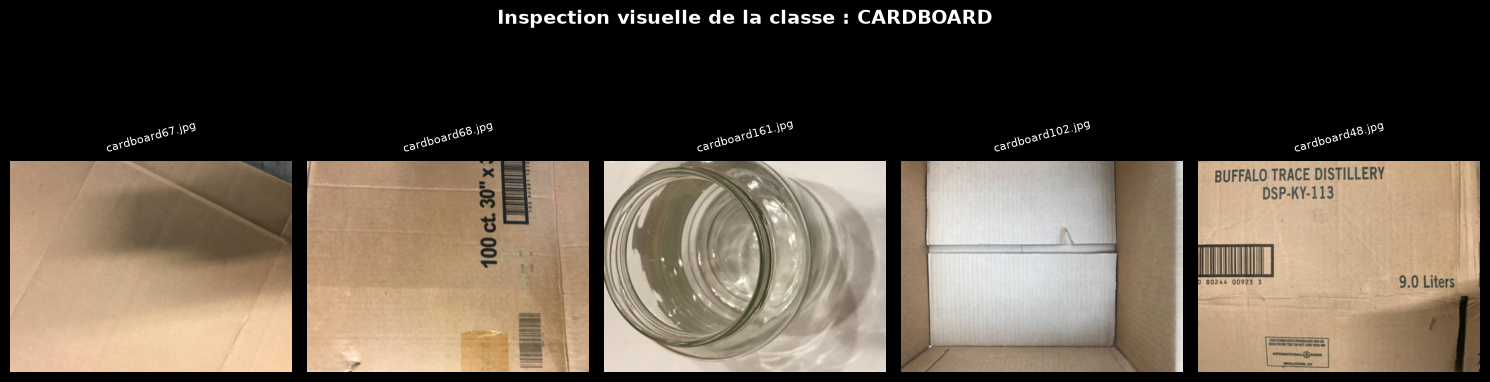

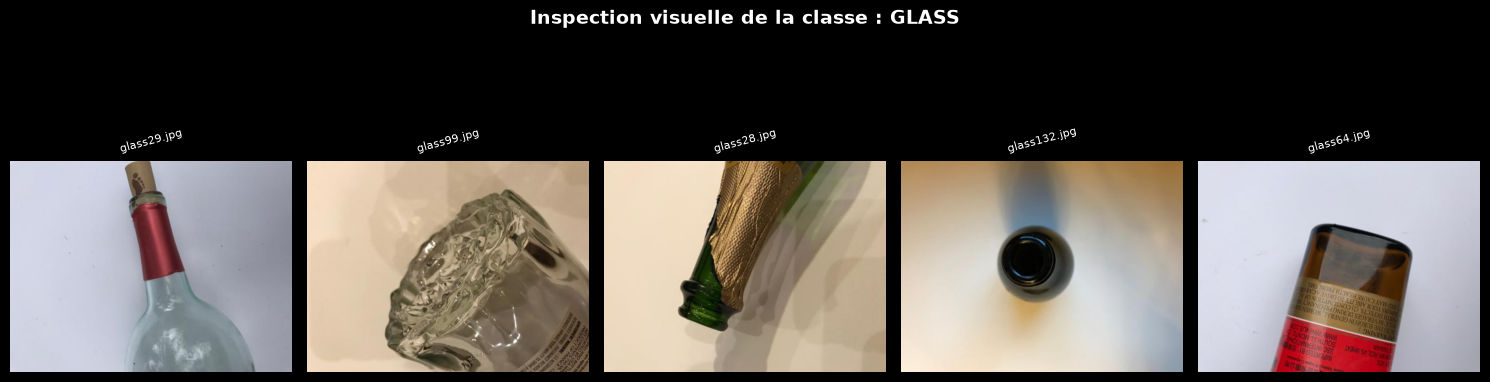

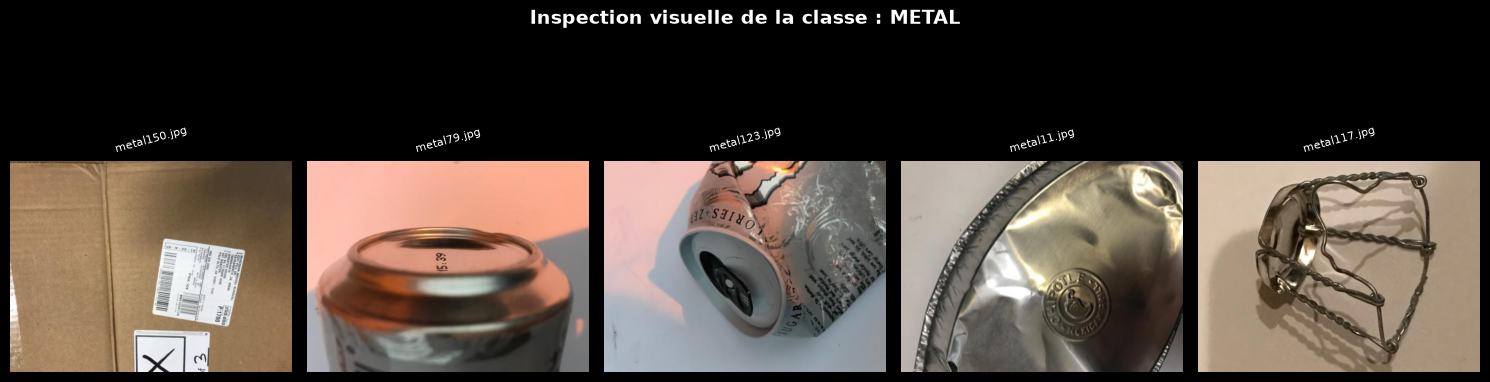

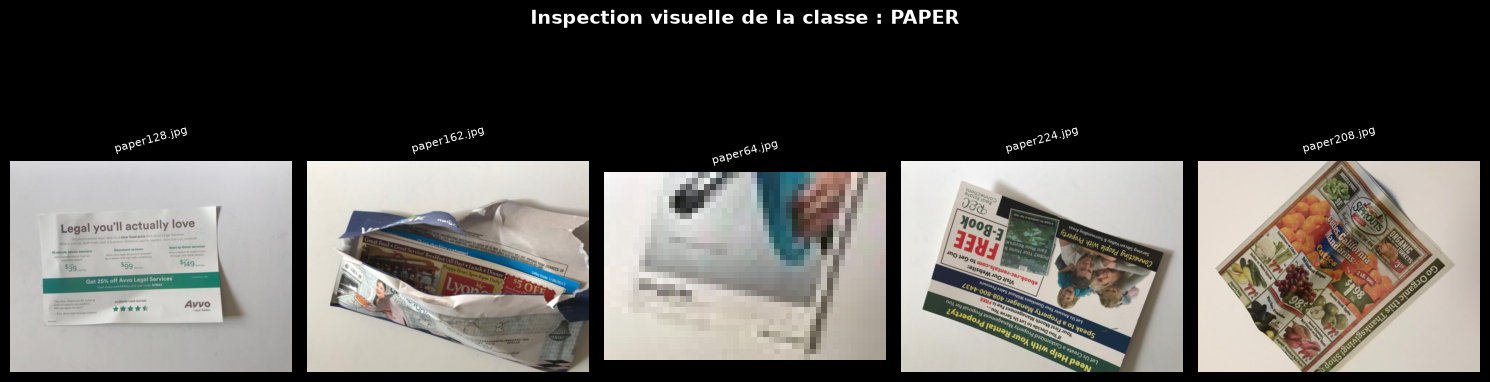

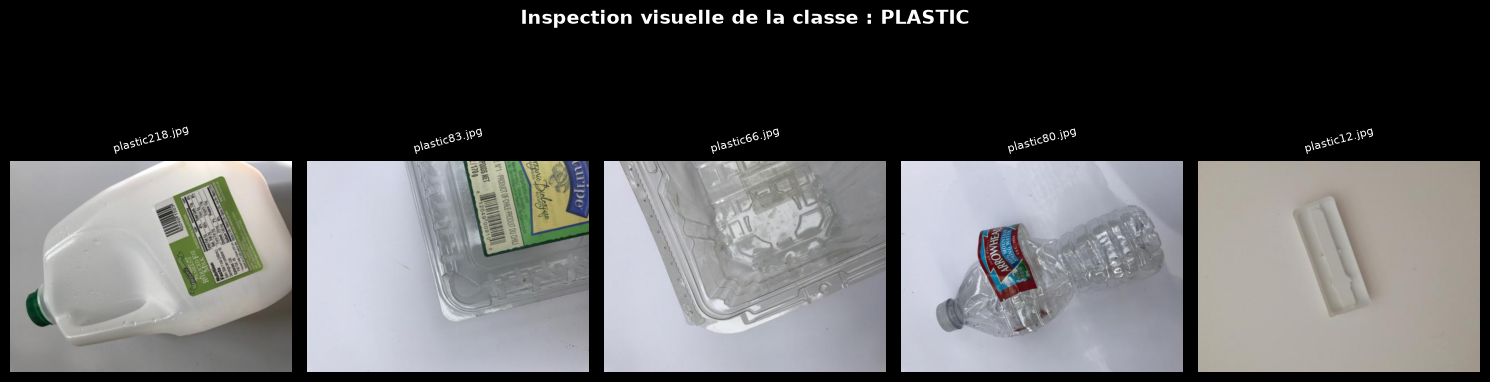

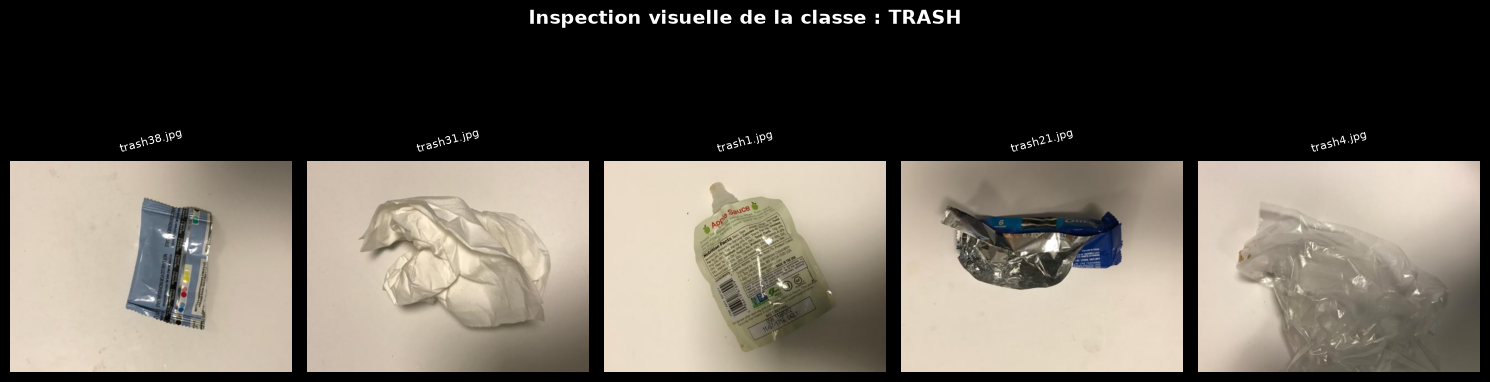

In [17]:
import random
import matplotlib.pyplot as plt


CHEMIN_RAW = "../data/raw"
plt.style.use('dark_background')

def inspecter_classe_visuellement(nom_classe, nb_images_a_afficher=6):
    """
    Affiche une grille d'images aléatoires appartenant à une classe spécifique
    pour permettre un contrôle visuel rapide.
    """
    chemin_classe = os.path.join(CHEMIN_RAW, nom_classe)
    
    if not os.path.exists(chemin_classe):
        print(f"Le dossier pour la classe '{nom_classe}' n'existe pas.")
        return

    # 1. Récupérer tous les fichiers valides (non cachés) du dossier
    tous_les_fichiers = [f for f in os.listdir(chemin_classe) if not f.startswith('.')]
    
    # Éviter de planter si le dossier contient moins d'images que demandé
    nb_images_a_afficher = min(len(tous_les_fichiers), nb_images_a_afficher)
    
    if nb_images_a_afficher == 0:
        print(f"Aucune image trouvée dans le dossier de la classe : {nom_classe}")
        return

    # 2. Sélectionner un échantillon aléatoire d'fichiers
    echantillon_fichiers = random.sample(tous_les_fichiers, nb_images_a_afficher)
    
    # 3. Configuration de l'affichage avec Matplotlib (grille de 1 ligne x N colonnes)
    fig, axes = plt.subplots(1, nb_images_a_afficher, figsize=(15, 5))
    fig.suptitle(f"Inspection visuelle de la classe : {nom_classe.upper()}", fontsize=14, fontweight='bold')
    
    # Si on demande 1 seule image, 'axes' n'est pas une liste, on l'ajuste
    if nb_images_a_afficher == 1:
        axes = [axes]

    # 4. Chargement et affichage de chaque image de l'échantillon
    for i, nom_fichier in enumerate(echantillon_fichiers):
        chemin_complet = os.path.join(chemin_classe, nom_fichier)
        try:
            with Image.open(chemin_complet) as img:
                axes[i].imshow(img)
                # On coupe les axes gradués pour une image plus propre
                axes[i].axis('off')
                # On affiche le nom du fichier sous l'image pour pouvoir le noter s'il est mal classé
                axes[i].set_title(nom_fichier, fontsize=8, rotation=15)
        except Exception:
            axes[i].text(0.5, 0.5, "Image\nCorrompue", ha='center', va='center')
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.show()

# EXÉCUTION DE L'INSPECTION VISUELLE -
# On liste toutes les classes présentes pour lancer l'affichage automatique
classes_disponibles = [d for d in os.listdir(CHEMIN_RAW) if os.path.isdir(os.path.join(CHEMIN_RAW, d))]

for classe in classes_disponibles:
    inspecter_classe_visuellement(classe, nb_images_a_afficher=5)


### <span style="color: #c20dfe">__Partie 8 : Analyse de déséquilibre des classes__</span> 

Déterminons le nombre d'images par classe 

Le déséquilibre des classes (class imbalance) se produit lorsqu'une catégorie possède beaucoup plus (ou beaucoup moins) d'exemples que les autres dans le jeu d'entraînement.

Mesurer ce déséquilibre va nous permettre de valider la nécessité d'appliquer des techniques correctives (comme la Data Augmentation ciblée 

ANALYSE DU DÉSÉQUILIBRE DES CLASSES 
- Classe 'paper' : 251 image(s) (24.46%)
- Classe 'plastic' : 223 image(s) (21.73%)
- Classe 'glass' : 187 image(s) (18.23%)
- Classe 'cardboard' : 168 image(s) (16.37%)
- Classe 'metal' : 148 image(s) (14.42%)
- Classe 'trash' : 49 image(s) (4.78%)


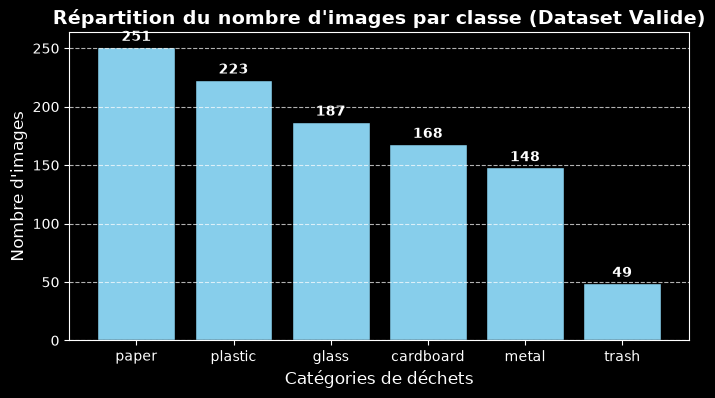

In [20]:
# 1. On ne garde que les images valides pour l'analyse des classes
df_valides = df_exploration[df_exploration["statut"] == "Valide"].copy()

# 2. Compter le nombre d'images par classe
repartition_classes = df_valides["classe"].value_counts()

# 3. Calculer le pourcentage pour chaque classe
pourcentages_classes = df_valides["classe"].value_counts(normalize=True) * 100

# AFFICHAGE DES RÉSULTATS TEXTUELS 
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES ")
for classe in repartition_classes.index:
    nb_images = repartition_classes[classe]
    pct = pourcentages_classes[classe]
    print(f"- Classe '{classe}' : {nb_images} image(s) ({pct:.2f}%)")

# GENERATION DU GRAPHIQUE 
plt.figure(figsize=(8, 4))
# Remplacer les couleurs par défaut par un dégradé de bleu pour le style
bars = plt.bar(repartition_classes.index, repartition_classes.values, color='skyblue', edgecolor='black')

# Ajout des valeurs numériques au-dessus de chaque barre pour une lecture rapide
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(repartition_classes.values)*0.01), 
             f"{yval}", ha='center', va='bottom', fontweight='bold')

plt.title("Répartition du nombre d'images par classe (Dataset Valide)", fontsize=14, fontweight='bold')
plt.xlabel("Catégories de déchets", fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Affichage du graphique dans le notebook
plt.show()


#### Complément : Création du rapport audit_images.csv

Puisqu'on vient de terminer toutes les phases d'analyse et de détection des anomalies, on peut désormais remplir le fichier demandé dans les consignes : reports/audit_images.csv.

In [21]:
# Extraction des métriques calculées lors des étapes précédentes
total_images_brutes = len(df_exploration)
nb_corrompues = len(df_exploration[df_exploration["statut"] == "Corrompu"])
nb_vides = len(images_vides) if 'images_vides' in locals() else 0
nb_trop_petites = len(df_trop_petites) if 'df_trop_petites' in locals() else 0
nb_doublons = len(doublons_detectes) if 'doublons_detectes' in locals() else 0

# Pour les images grayscale (1 canal) et RGBA (4 canaux)
nb_grayscale = len(df_valides[df_valides["canaux"] == 1])
nb_rgba = len(df_valides[df_valides["canaux"] == 4])

# (Optionnel) Si on a noté manuellement des images mal classées à l'étape 7
nb_mal_classees = 0 # Ajuster la valeur si des intrus ont été isolés

# Création du dictionnaire pour le rapport d'audit
donnees_audit = {
    "Indicateur d'Audit": [
        "Total d'images", 
        "Images corrompues", 
        "Images quasi vides", 
        "Images trop petites", 
        "Doublons",
        "Images grayscale", 
        "Images RGBA", 
        "Images mal classées"
    ],
    "Quantité": [
        total_images_brutes, 
        nb_corrompues, 
        nb_vides, 
        nb_trop_petites, 
        nb_doublons, 
        nb_grayscale, 
        nb_rgba, 
        nb_mal_classees
    ]
}

# Conversion et sauvegarde en CSV
df_audit_final = pd.DataFrame(donnees_audit)
chemin_rapport = "../reports/audit_images.csv"

# Création du dossier reports s'il n'existe pas
os.makedirs("../reports", exist_ok=True)
df_audit_final.to_csv(chemin_rapport, index=False)

print(f"\n[SUCCÈS] Le rapport de synthèse a été enregistré dans : {chemin_rapport}")
print(df_audit_final.to_string(index=False))



[SUCCÈS] Le rapport de synthèse a été enregistré dans : ../reports/audit_images.csv
 Indicateur d'Audit  Quantité
     Total d'images      1032
  Images corrompues         6
 Images quasi vides         4
Images trop petites        13
           Doublons        15
   Images grayscale         2
        Images RGBA        18
Images mal classées         0


### <span style="color: #c20dfe">__Partie 9 : Redimensionnement__</span>

Redimensionnons toutes les images à 224 × 224. 

On passe maintenant à la phase active de transformation ! À partir de cette étape, on va commencer à alimenter notre dossier propre : data/cleaned/.

Comme l'indique la consigne, le dossier original data/raw/ doit rester en lecture seule. On va donc lire les images brutes de data/raw/, appliquer nos transformations, puis sauvegarder le résultat dans data/cleaned/.

 Pourquoi conserver les proportions avec du padding ?
 
 Si on redimensionne brutalement une image rectangulaire (par exemple une canette allongée de (400 x 200) pixels) vers un format carré de (224 x 224) pixels, l'image va être écrasée ou étirée. Cette déformation géométrique modifie l'aspect réel de l'objet et va rendre l'apprentissage plus difficile pour le réseau de neurones. 
 
 Pour éviter cela, on utilise la technique du redimensionnement avec conservation du ratio (proportions) et ajout de remplissage (padding)

In [23]:
# Fonction de redimensionnement intelligent avec padding pour les images
def redimensionner_avec_padding(chemin_image_source, taille_cible=(224, 224), couleur_fond=(0, 0, 0)):
    """
    Redimensionne une image vers une taille carrée cible en conservant ses proportions.
    Ajoute des bandes de couleur (padding) pour combler le vide si nécessaire.
    """
    with Image.open(chemin_image_source) as img:
        # 1. On sauvegarde le mode d'origine pour les étapes suivantes (ex: RGB, L)
        mode_origine = img.mode
        
        # 2. Calcul du ratio pour conserver les proportions
        # La méthode thumbnail modifie l'image en place en respectant le ratio maximal
        img.thumbnail(taille_cible, Image.Resampling.LANCZOS)
        
        # 3. Création d'une nouvelle image carrée vide (fond noir par défaut)
        image_carree = Image.new(mode_origine, taille_cible, couleur_fond)
        
        # 4. Calcul de la position pour centrer l'image d'origine sur le fond carré
        position_x = (taille_cible[0] - img.size[0]) // 2
        position_y = (taille_cible[1] - img.size[1]) // 2
        
        # 5. On colle l'image modifiée sur l'image carrée
        image_carree.paste(img, (position_x, position_y))
        
        return image_carree


Traitement global et création de data/cleaned/

On créer une boucle qui parcourt notre liste d'images valides, applique la fonction, et crée la structure de dossiers nettoyée.

In [24]:
# On prépare le dictionnaire des empreintes déjà vues pour éliminer les doublons physiques ici
empreintes_deja_traitees = set()

CHEMIN_RAW = "../data/raw"
CHEMIN_CLEANED = "../data/cleaned"

# Compteurs pour notre bilan
images_sauvegardees = 0
images_ignorees_anomalies = 0

print("Début du redimensionnement et de la copie vers 'data/cleaned'...")

for nom_classe in os.listdir(CHEMIN_RAW):
    chemin_classe_raw = os.path.join(CHEMIN_RAW, nom_classe)
    chemin_classe_cleaned = os.path.join(CHEMIN_CLEANED, nom_classe)
    
    if os.path.isdir(chemin_classe_raw):
        # Création automatique du sous-dossier de la classe dans 'cleaned' s'il n'existe pas
        os.makedirs(chemin_classe_cleaned, exist_ok=True)
        
        for nom_fichier in os.listdir(chemin_classe_raw):
            if nom_fichier.startswith('.'):
                continue
                
            chemin_complet_raw = os.path.join(chemin_classe_raw, nom_fichier)
            
            # FILTRES DE SÉCURITÉ (Audit des parties précédentes) 
            
            # 1. Ignorer si corrompu
            if est_image_corrompue(chemin_complet_raw):
                images_ignorees_anomalies += 1
                continue
                
            # 2. Ignorer si vide
            if est_image_vide(chemin_complet_raw):
                images_ignorees_anomalies += 1
                continue
                
            # 3. Ignorer si trop petite (< 64x64)
            with Image.open(chemin_complet_raw) as test_img:
                largeur, hauteur = test_img.size
            if largeur < 64 or hauteur < 64:
                images_ignorees_anomalies += 1
                continue
                
            # 4. Ignorer si c'est un doublon d'un fichier déjà copié
            empreinte = calculer_empreinte_md5(chemin_complet_raw)
            if empreinte in empreintes_deja_traitees:
                # C'est un doublon, on l'écarte !
                continue
            else:
                empreintes_deja_traitees.add(empreinte)

            # --- APPLICATION DE LA TRANSFORMATION ---
            try:
                # Appel de notre fonction intelligente
                image_redimensionnee = redimensionner_avec_padding(chemin_complet_raw, taille_cible=(224, 224))
                
                # Définition du chemin de destination propre
                chemin_complet_cleaned = os.path.join(chemin_classe_cleaned, nom_fichier)
                
                # Sauvegarde physique du nouveau fichier
                image_redimensionnee.save(chemin_complet_cleaned)
                images_sauvegardees += 1
                
            except Exception as e:
                print(f"Erreur inattendue sur le fichier {nom_fichier} : {e}")

print("\nBILAN DU PIPELINE DE NETTOYAGE ET REDIMENSIONNEMENT ²")
print(f"Nombre total d'images saines, uniques et redimensionnées créées dans 'data/cleaned/' : {images_sauvegardees}")
print(f"Nombre d'images écartées (corrompues, vides ou trop petites) : {images_ignorees_anomalies}")


Début du redimensionnement et de la copie vers 'data/cleaned'...
Erreur inattendue sur le fichier metal13z.jpg : cannot write mode RGBA as JPEG
Erreur inattendue sur le fichier metal62rt.jpg : cannot write mode RGBA as JPEG

BILAN DU PIPELINE DE NETTOYAGE ET REDIMENSIONNEMENT ²
Nombre total d'images saines, uniques et redimensionnées créées dans 'data/cleaned/' : 994
Nombre d'images écartées (corrompues, vides ou trop petites) : 23


L'explication technique : Ces deux images possèdent l'extension .jpg mais sont en réalité codées en mode RGBA (avec un canal de transparence). 

Le format standard JPEG ne supporte pas la transparence. Quand Pillow a essayé de sauvegarder ces images modifiées en conservant leur mode RGBA d'origine dans un fichier d'extension .jpg, le code a planté.

### <span style="color: #c20dfe">__Partie 10 : Uniformisation des canaux__</span>

Convertir toutes les images en RGB 

L'objectif de cette partie est de s'assurer que les 994 images de notre dossier data/cleaned/ possèdent strictement 3 canaux (RGB). On va convertir les modes transparents (RGBA) et les formats spéciaux ou indexés (le mode 'P' qu'on a détecté dans le rapport pour 2 images).

Pour faire propre et ne pas laisser de fichiers de côté, on va modifier légèrement notre fonction de redimensionnement pour qu'elle force le passage en RGB avant la sauvegarde.

In [25]:
# Le Code de correction
CHEMIN_RAW = "../data/raw"
CHEMIN_CLEANED = "../data/cleaned"

def redimensionner_et_convertir_rgb(chemin_image_source, taille_cible=(224, 224)):
    """
    Ouvre une image, la convertit obligatoirement en mode RGB (3 canaux),
    puis la redimensionne avec du padding noir.
    """
    with Image.open(chemin_image_source) as img:
        # UNIFORMISATION DES CANAUX : Conversion forcée en RGB
        # S'il y a de la transparence (RGBA), on crée un fond noir pour l'aplatir
        if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
            img_rgb = Image.new("RGB", img.size, (0, 0, 0))
            # On colle l'image d'origine en utilisant le canal Alpha comme masque
            img_rgb.paste(img, mask=img.split()[-1]) 
        else:
            # Pour les modes RGB classiques ou Grayscale ('L' ou 'P' standard)
            img_rgb = img.convert("RGB")
            
        # Redimensionnement avec conservation des proportions
        img_rgb.thumbnail(taille_cible, Image.Resampling.LANCZOS)
        
        # Création du fond noir final au format RGB
        image_finale = Image.new("RGB", taille_cible, (0, 0, 0))
        
        # Centrage de l'image
        position_x = (taille_cible[0] - img_rgb.size[0]) // 2
        position_y = (taille_cible[1] - img_rgb.size[1]) // 2
        image_finale.paste(img_rgb, (position_x, position_y))
        
        return image_finale

# --- RELANCE DU PIPELINE DE NETTOYAGE ---
empreintes_deja_traitees = set()
images_sauvegardees = 0

print("Application de l'uniformisation RGB globale...")

for nom_classe in os.listdir(CHEMIN_RAW):
    chemin_classe_raw = os.path.join(CHEMIN_RAW, nom_classe)
    chemin_classe_cleaned = os.path.join(CHEMIN_CLEANED, nom_classe)
    
    if os.path.isdir(chemin_classe_raw):
        os.makedirs(chemin_classe_cleaned, exist_ok=True)
        
        for nom_fichier in os.listdir(chemin_classe_raw):
            if nom_fichier.startswith('.'): continue
            chemin_complet_raw = os.path.join(chemin_classe_raw, nom_fichier)
            
            # Application des filtres de sécurité validés précédemment
            if est_image_corrompue(chemin_complet_raw) or est_image_vide(chemin_complet_raw):
                continue
            with Image.open(chemin_complet_raw) as test_img:
                if test_img.size[0] < 64 or test_img.size[1] < 64: continue
            
            # Élimination des doublons
            empreinte = calculer_empreinte_md5(chemin_complet_raw)
            if empreinte in empreintes_deja_traitees: continue
            empreintes_deja_traitees.add(empreinte)
            
            # Traitement et Sauvegarde
            try:
                img_propre = redimensionner_et_convertir_rgb(chemin_complet_raw)
                img_propre.save(os.path.join(chemin_classe_cleaned, nom_fichier))
                images_sauvegardees += 1
            except Exception as e:
                print(f"Erreur sur {nom_fichier} : {e}")

print(f"\n[SUCCÈS] Toutes les images saines ({images_sauvegardees}) sont maintenant carrées et au format RGB pur !")


Application de l'uniformisation RGB globale...
Erreur sur image-violet-512x384.gif : bad transparency mask

[SUCCÈS] Toutes les images saines (995) sont maintenant carrées et au format RGB pur !


### <span style="color: #c20dfe">__Partie 11 : Mise à l'échelle des pixels__</span>

#### Normalisation

Pourquoi normaliser les pixels ?

En informatique, une image couleur RGB est un tableau de nombres. 

Pour chaque pixel, il y a 3 valeurs (Rouge, Vert, Bleu) comprises entre 0 (aucune intensité) et 255 (intensité maximale).

Si on injecte directement ces valeurs (allant de 0 à 255) dans un réseau de neurones, on s'expose à deux gros problèmes :

* L'instabilité des calculs : Les fonctions mathématiques à l'intérieur du modèle (comme les fonctions d'activation ou 
le calcul des gradients) ont du mal à gérer des grands écarts de nombres.
Cela peut ralentir ou bloquer l'apprentissage.

* L'importance disproportionnée : Le modèle pourrait penser qu'un pixel à 255 a "plus d'importance" qu'un pixel à 12, 
simplement parce que le chiffre est plus grand.

La solution : On divise toutes les valeurs par 255.0. Ainsi, tous les pixels de notre dataset se 
retrouvent compressés dans une échelle uniforme comprise strictement entre 0.0 et 1.0. 
Les calculs deviennent stables, fluides et beaucoup plus rapides.

Comment intégrer cela en pratique ?

Dans un vrai projet de Deep Learning, la normalisation ne se fait généralement pas en réenregistrant les images sur le disque dur (car les fichiers PNG/JPEG n'enregistrent que des nombres entiers de 0 à 255).

La normalisation s'applique au moment du chargement des images en mémoire juste avant d'entrer dans l'IA, sous forme de "tenseurs" (tableaux Numpy ou tenseurs PyTorch/TensorFlow).

In [28]:
import numpy as np

def charger_et_normaliser_image(chemin_image_cleaned):
    """
    Charge une image nettoyée, la convertit en tableau Numpy,
    et normalise la valeur de ses pixels entre 0.0 et 1.0.
    """
    # 1. Ouverture de l'image carrée RGB
    with Image.open(chemin_image_cleaned) as img:
        # 2. Conversion en tableau de nombres Numpy (contenant des entiers de 0 à 255)
        tableau_pixels = np.array(img)
        
        # 3. Normalisation : conversion en nombres décimaux (float32) et division par 255
        tableau_normalise = tableau_pixels.astype(np.float32) / 255.0
        
        return tableau_normalise

# --- DÉMONSTRATION SUR UNE IMAGE ---
# On pioche la toute première image de carton nettoyée pour voir le résultat mathématique
exemple_chemin = "../data/cleaned/cardboard/cardboard1.jpg"

try:
    matrice_normalisee = charger_et_normaliser_image(exemple_chemin)
    
    print("VÉRIFICATION DE LA NORMALISATION ")
    print(f"Format de la matrice (Hauteur, Largeur, Canaux) : {matrice_normalisee.shape}")
    print(f"Valeur minimale d'un pixel après normalisation : {matrice_normalisee.min()}")
    print(f"Valeur maximale d'un pixel après normalisation : {matrice_normalisee.max()}")
    print("\nExtrait des valeurs normalisées du premier pixel (RGB) :")
    print(matrice_normalisee[0, 0]) # Affiche les 3 canaux du pixel tout en haut à gauche
except Exception as e:
    print(f"Impossible de tester l'image d'exemple : {e}")


VÉRIFICATION DE LA NORMALISATION 
Format de la matrice (Hauteur, Largeur, Canaux) : (224, 224, 3)
Valeur minimale d'un pixel après normalisation : 0.0
Valeur maximale d'un pixel après normalisation : 1.0

Extrait des valeurs normalisées du premier pixel (RGB) :
[0. 0. 0.]


En imprimant les valeurs, on remarque que l'on n'a plus d'entiers comme 150, 45 ou 200, 
mais des nombres décimaux comme 0.588, 0.176 ou 0.784. 

Nos images sont mathématiquement prête à être digérée par un réseau de neurone.